In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import netCDF4 as nc
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator, WeekdayLocator, DateFormatter
from netCDF4 import Dataset, num2date
from datetime import datetime, timedelta
from collections import deque
from mpl_toolkits.basemap import Basemap
import os, fnmatch

In [2]:
def find_files(directory, pattern, maxdepth=None):
    flist = []
    for root, dirs, files in os.walk(directory):
        for basename in files:
            if fnmatch.fnmatch(basename, pattern):
                filename = os.path.join(root, basename)
                filename = filename.replace('\\\\', os.sep)
                if maxdepth is None:
                    flist.append(filename)
                else:
                    if filename.count(os.sep)-directory.count(os.sep) <= maxdepth:
                        flist.append(filename)
    return flist

In [3]:
def drawing(lon, lat, data, region, data_type, day):
    fig = plt.figure(figsize=(12, 12), dpi = 300)
    
    if region == 'Kara':
        m = Basemap(width=1800000, height=1300000,
                    resolution='l', projection='aea',
                    lat_1=50, lat_2=55, lon_0=70, lat_0=74)
        s = 30
        fontsize = 10
        borders = [15, 27]
        
    elif region == 'EastSib':
        m = Basemap(width=3500000,height=1500000,
                    resolution='l',projection='aea',
                    lat_1=60, lat_2=65, lon_0=140, lat_0=76)
        s = 5
        fontsize = 8
        borders = [15, 25]
        
    m.drawcoastlines()
    m.fillcontinents(color='grey',lake_color='white')
    m.drawparallels(np.arange(-80.,80.,2.), labels=[True,False,True,False])
    m.drawmeridians(np.arange(-180.,180.,5.), labels=[False,True,False,True], latmax=90)
    m.drawmapboundary(fill_color='white')
    if data_type == 'sss':
        m.scatter(lon, lat, s=s, c=data,
                  cmap='jet', marker='o', latlon=True, vmin=4, vmax=36)
        cbar=plt.colorbar(label='Соленость', orientation='vertical', shrink=0.30)
        cbar.set_ticks([5,10,15,20,25,30,35])
        cs = m.contour(lon, lat, data, levels=borders, colors=['blue', 'red'], latlon=True)
        
    elif data_type == 'sst':
        m.scatter(lon, lat, s=s, c=data,
                  cmap='jet', marker='o', latlon=True, vmin=0, vmax=12)
        cbar=plt.colorbar(label='Температура', orientation='vertical', shrink=0.30)
        cbar.set_ticks([0,1,2,3,4,5,6,7,8,9,10,11,12])
    plt.title(f'{day}')
    font = {'size'   : fontsize}
    plt.rc('font', **font)
    ax = plt.gca()
    plt.show()
    plt.clf()
    plt.close('all')

In [4]:
year = 2019
start = '0801'
finish = '0930'

In [5]:
files = find_files(f'/mnt/hippocamp/DATA/sattelite/ESACCI/v05.5/NHv5.5/7days/{year}/', '*.nc')
files.sort()

In [6]:
files[214]

'/mnt/hippocamp/DATA/sattelite/ESACCI/v05.5/NHv5.5/7days/2019/ESACCI-SEASURFACESALINITY-L4-SSS-POLAR-MERGED_OI_7DAY_RUNNINGMEAN_DAILY_25kmEASE2_NH-20190803-fv5.5.nc'

In [ ]:
files = [f for f in files if f[-13:-9] >= start and f[-13:-9] <= finish]

In [ ]:
for f in files:
    data = Dataset(f, 'r')
    
    latitude = np.asarray(data['lat'])
    longitude = np.asarray(data['lon'])
    sss = np.asarray(data['sss'])
    
    drawing(lon=longitude, lat=latitude, data=sss, region='Kara', data_type='sss', day=f[-17:-9])

In [7]:
data = Dataset(files[214], 'r')

In [8]:
data.variables

{'lat': <class 'netCDF4.Variable'>
 float32 lat(dimy, dimx)
     _FillValue: nan
     long_name: latitude
     units: degrees_north
     standard_name: latitude
     valid_min: -90.0
     valid_max: 90.0
 unlimited dimensions: 
 current shape = (392, 392)
 filling on,
 'lon': <class 'netCDF4.Variable'>
 float32 lon(dimy, dimx)
     _FillValue: nan
     long_name: longitude
     units: degrees_east
     standard_name: longitude
     valid_min: -180.0
     valid_max: 180.0
 unlimited dimensions: 
 current shape = (392, 392)
 filling on,
 'time': <class 'netCDF4.Variable'>
 float32 time(time)
     _FillValue: nan
     long_name: time
     units: days since 1970-01-01 00:00:00 UTC
     standard_name: time
     calendar: standard
 unlimited dimensions: time
 current shape = (1,)
 filling on,
 'sss': <class 'netCDF4.Variable'>
 float32 sss(time, dimy, dimx)
     _FillValue: nan
     coordinates: time lat lon
     long_name: Unbiased merged Sea Surface Salinity
     standard_name: sea_surface

In [9]:
latitude = np.asarray(data['lat'])
longitude = np.asarray(data['lon'])

In [10]:
latitude.shape, longitude.shape

((392, 392), (392, 392))

In [11]:
latitude.min(), latitude.max()

(24.394566, 89.84173)

In [12]:
sss = np.asarray(data['sss'])[0]

In [13]:
sss.shape

(392, 392)

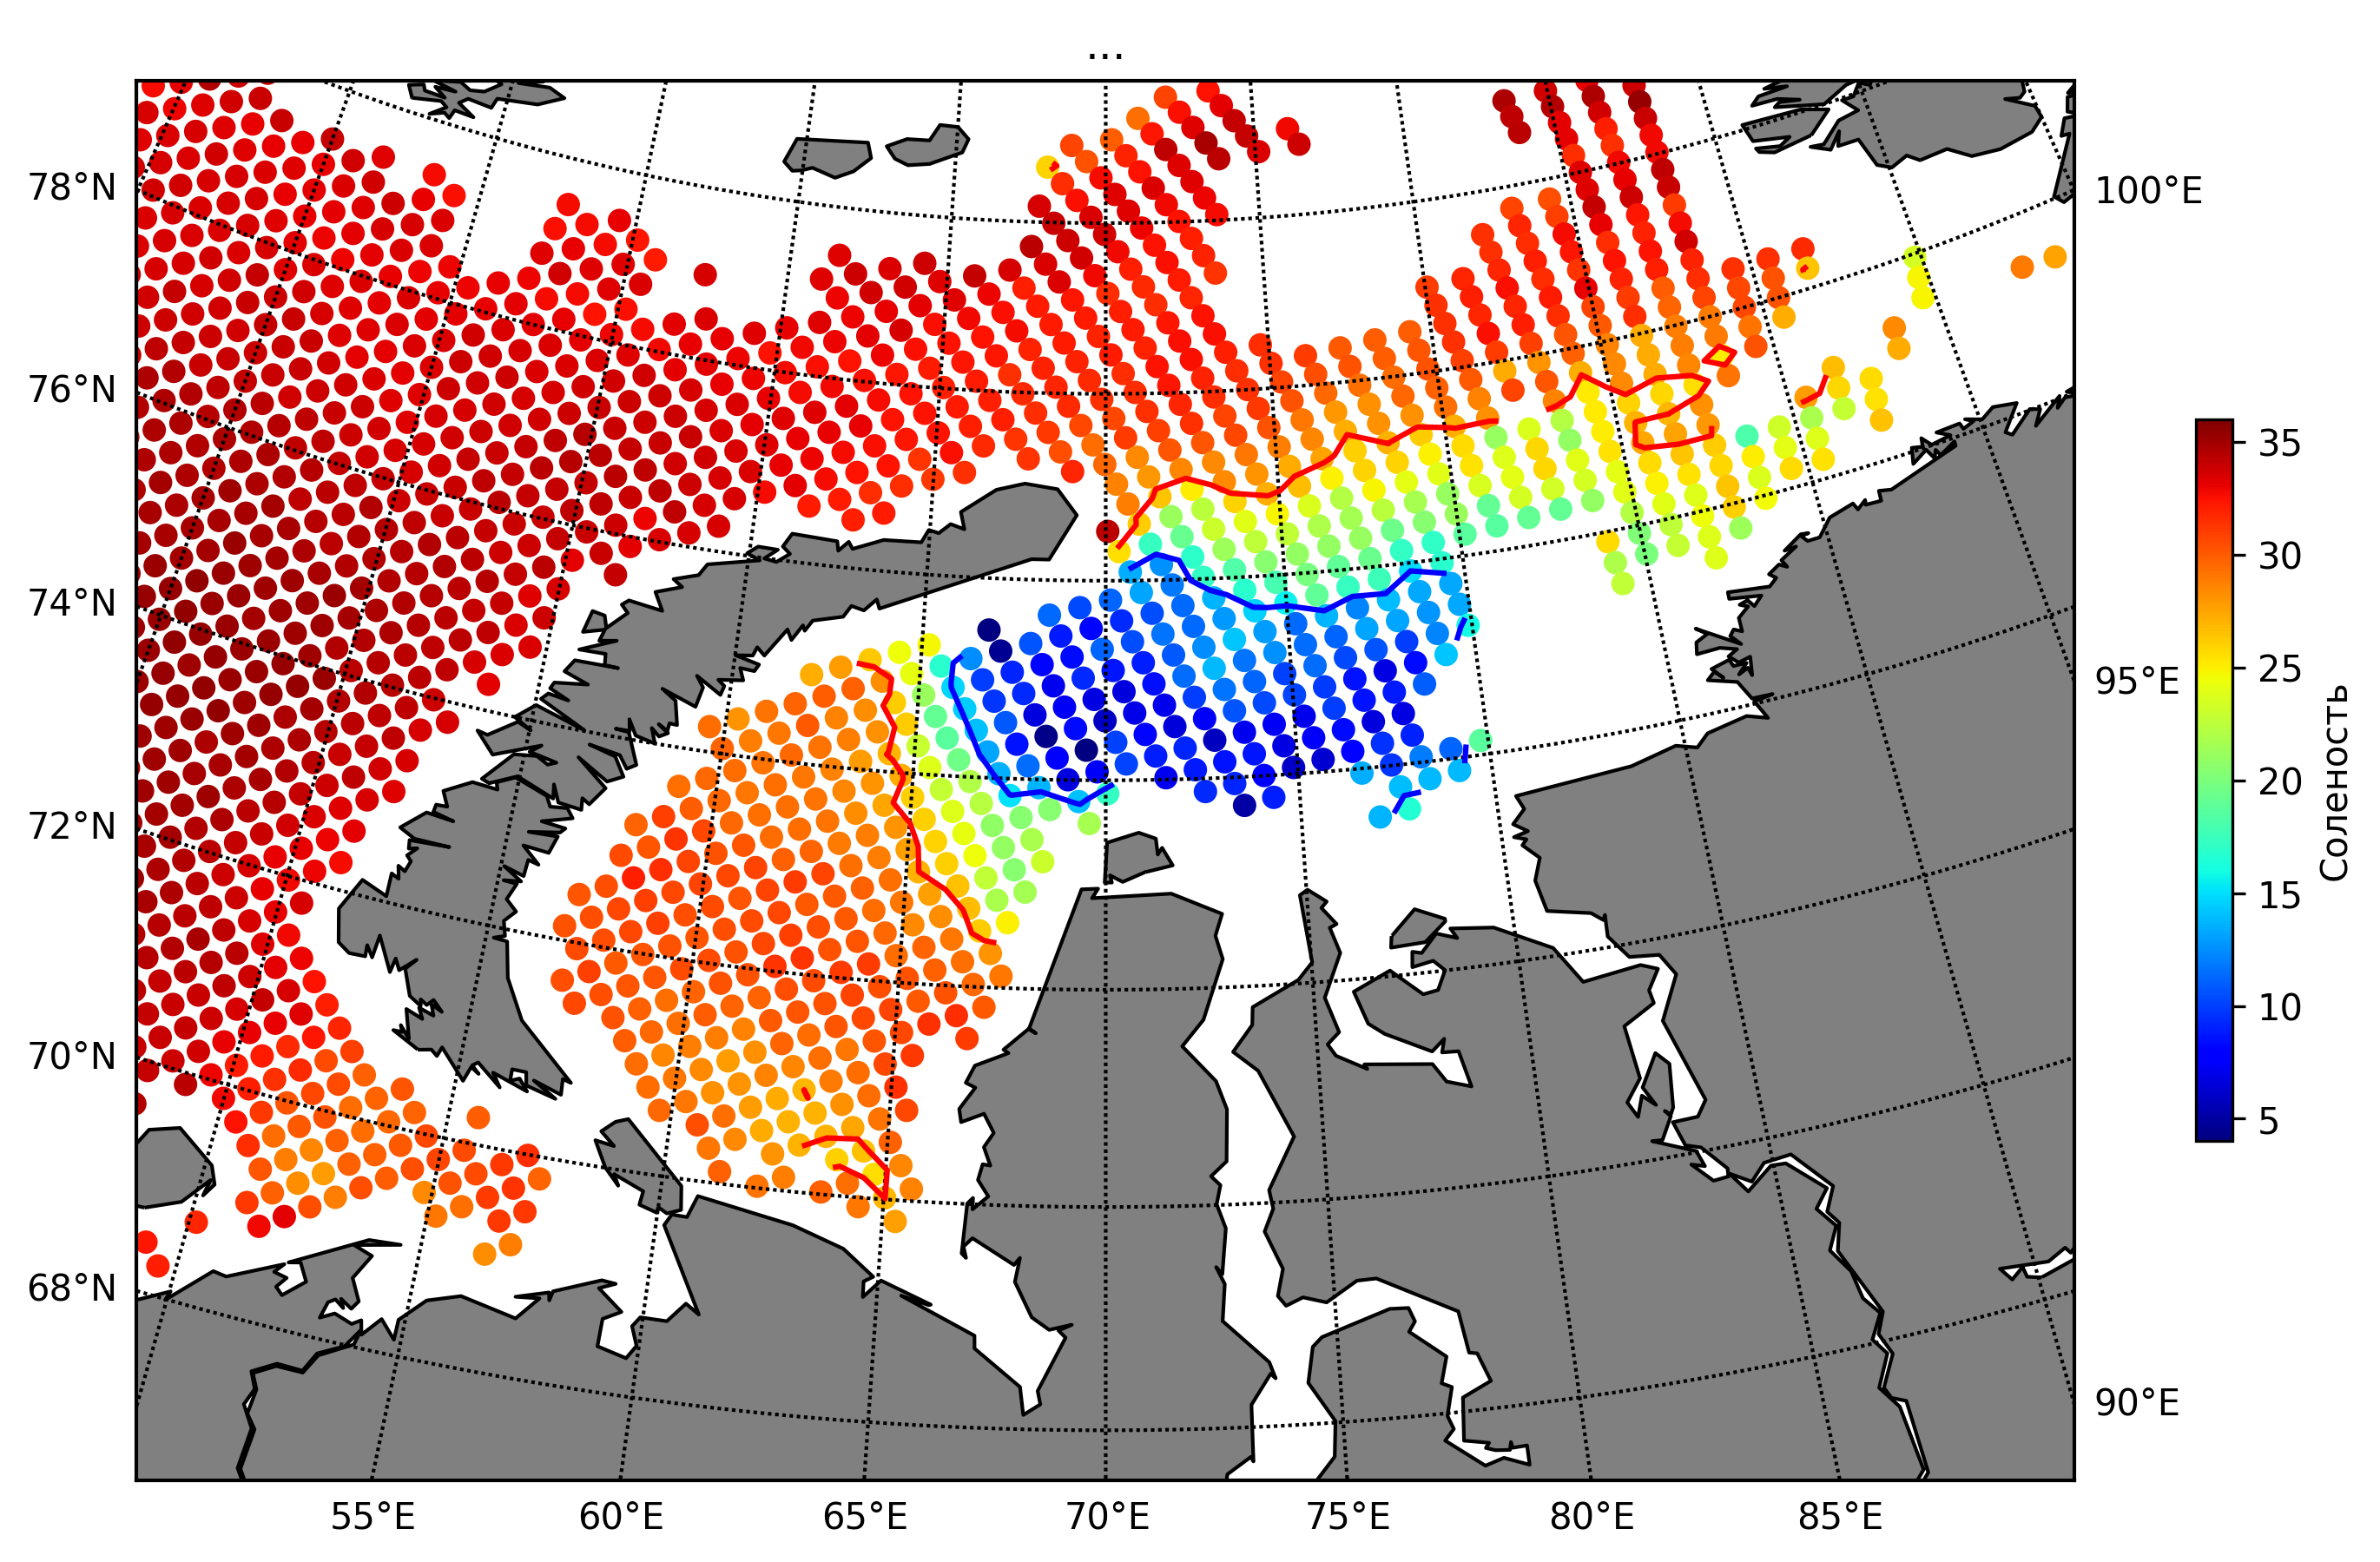

In [14]:
drawing(lon=longitude, lat=latitude, data=sss, region='Kara', data_type='sss', day='...')

In [15]:
def select_data(longitude, latitude, sss, borders):
    n, s, w, e, = borders
    mask = (latitude >= s) & (latitude <= n) & (longitude >= w) & (longitude <= e)
    
    rows_with_data = np.any(mask, axis=1)
    cols_with_data = np.any(mask, axis=0)

    row_idx = np.where(rows_with_data)[0]
    col_idx = np.where(cols_with_data)[0]

    lon = longitude[row_idx.min():row_idx.max() + 1,
                    col_idx.min():col_idx.max() + 1]
    
    lat = latitude[row_idx.min():row_idx.max() + 1,
               col_idx.min():col_idx.max() + 1]
    
    sss_ = sss[row_idx.min():row_idx.max() + 1,
            col_idx.min():col_idx.max() + 1]
    
    return lon, lat, sss_

In [18]:
lon, lat, sss_ = select_data(longitude=longitude, latitude=latitude, sss=sss, borders=[83,67,30,110])

In [ ]:
lat.shape, lon.shape, sss_.shape

In [ ]:
drawing(lon=lon, lat=lat, data=sss_, region='Kara', data_type='sss', day='...')

In [19]:
lon, lat, sss_ = select_data(longitude=longitude, latitude=latitude, sss=sss, borders=[80,70,55,105])
lon.shape, lat.shape, sss_.shape

((74, 52), (74, 52), (74, 52))

In [22]:
np.count_nonzero(~np.isnan(sss_))

1344

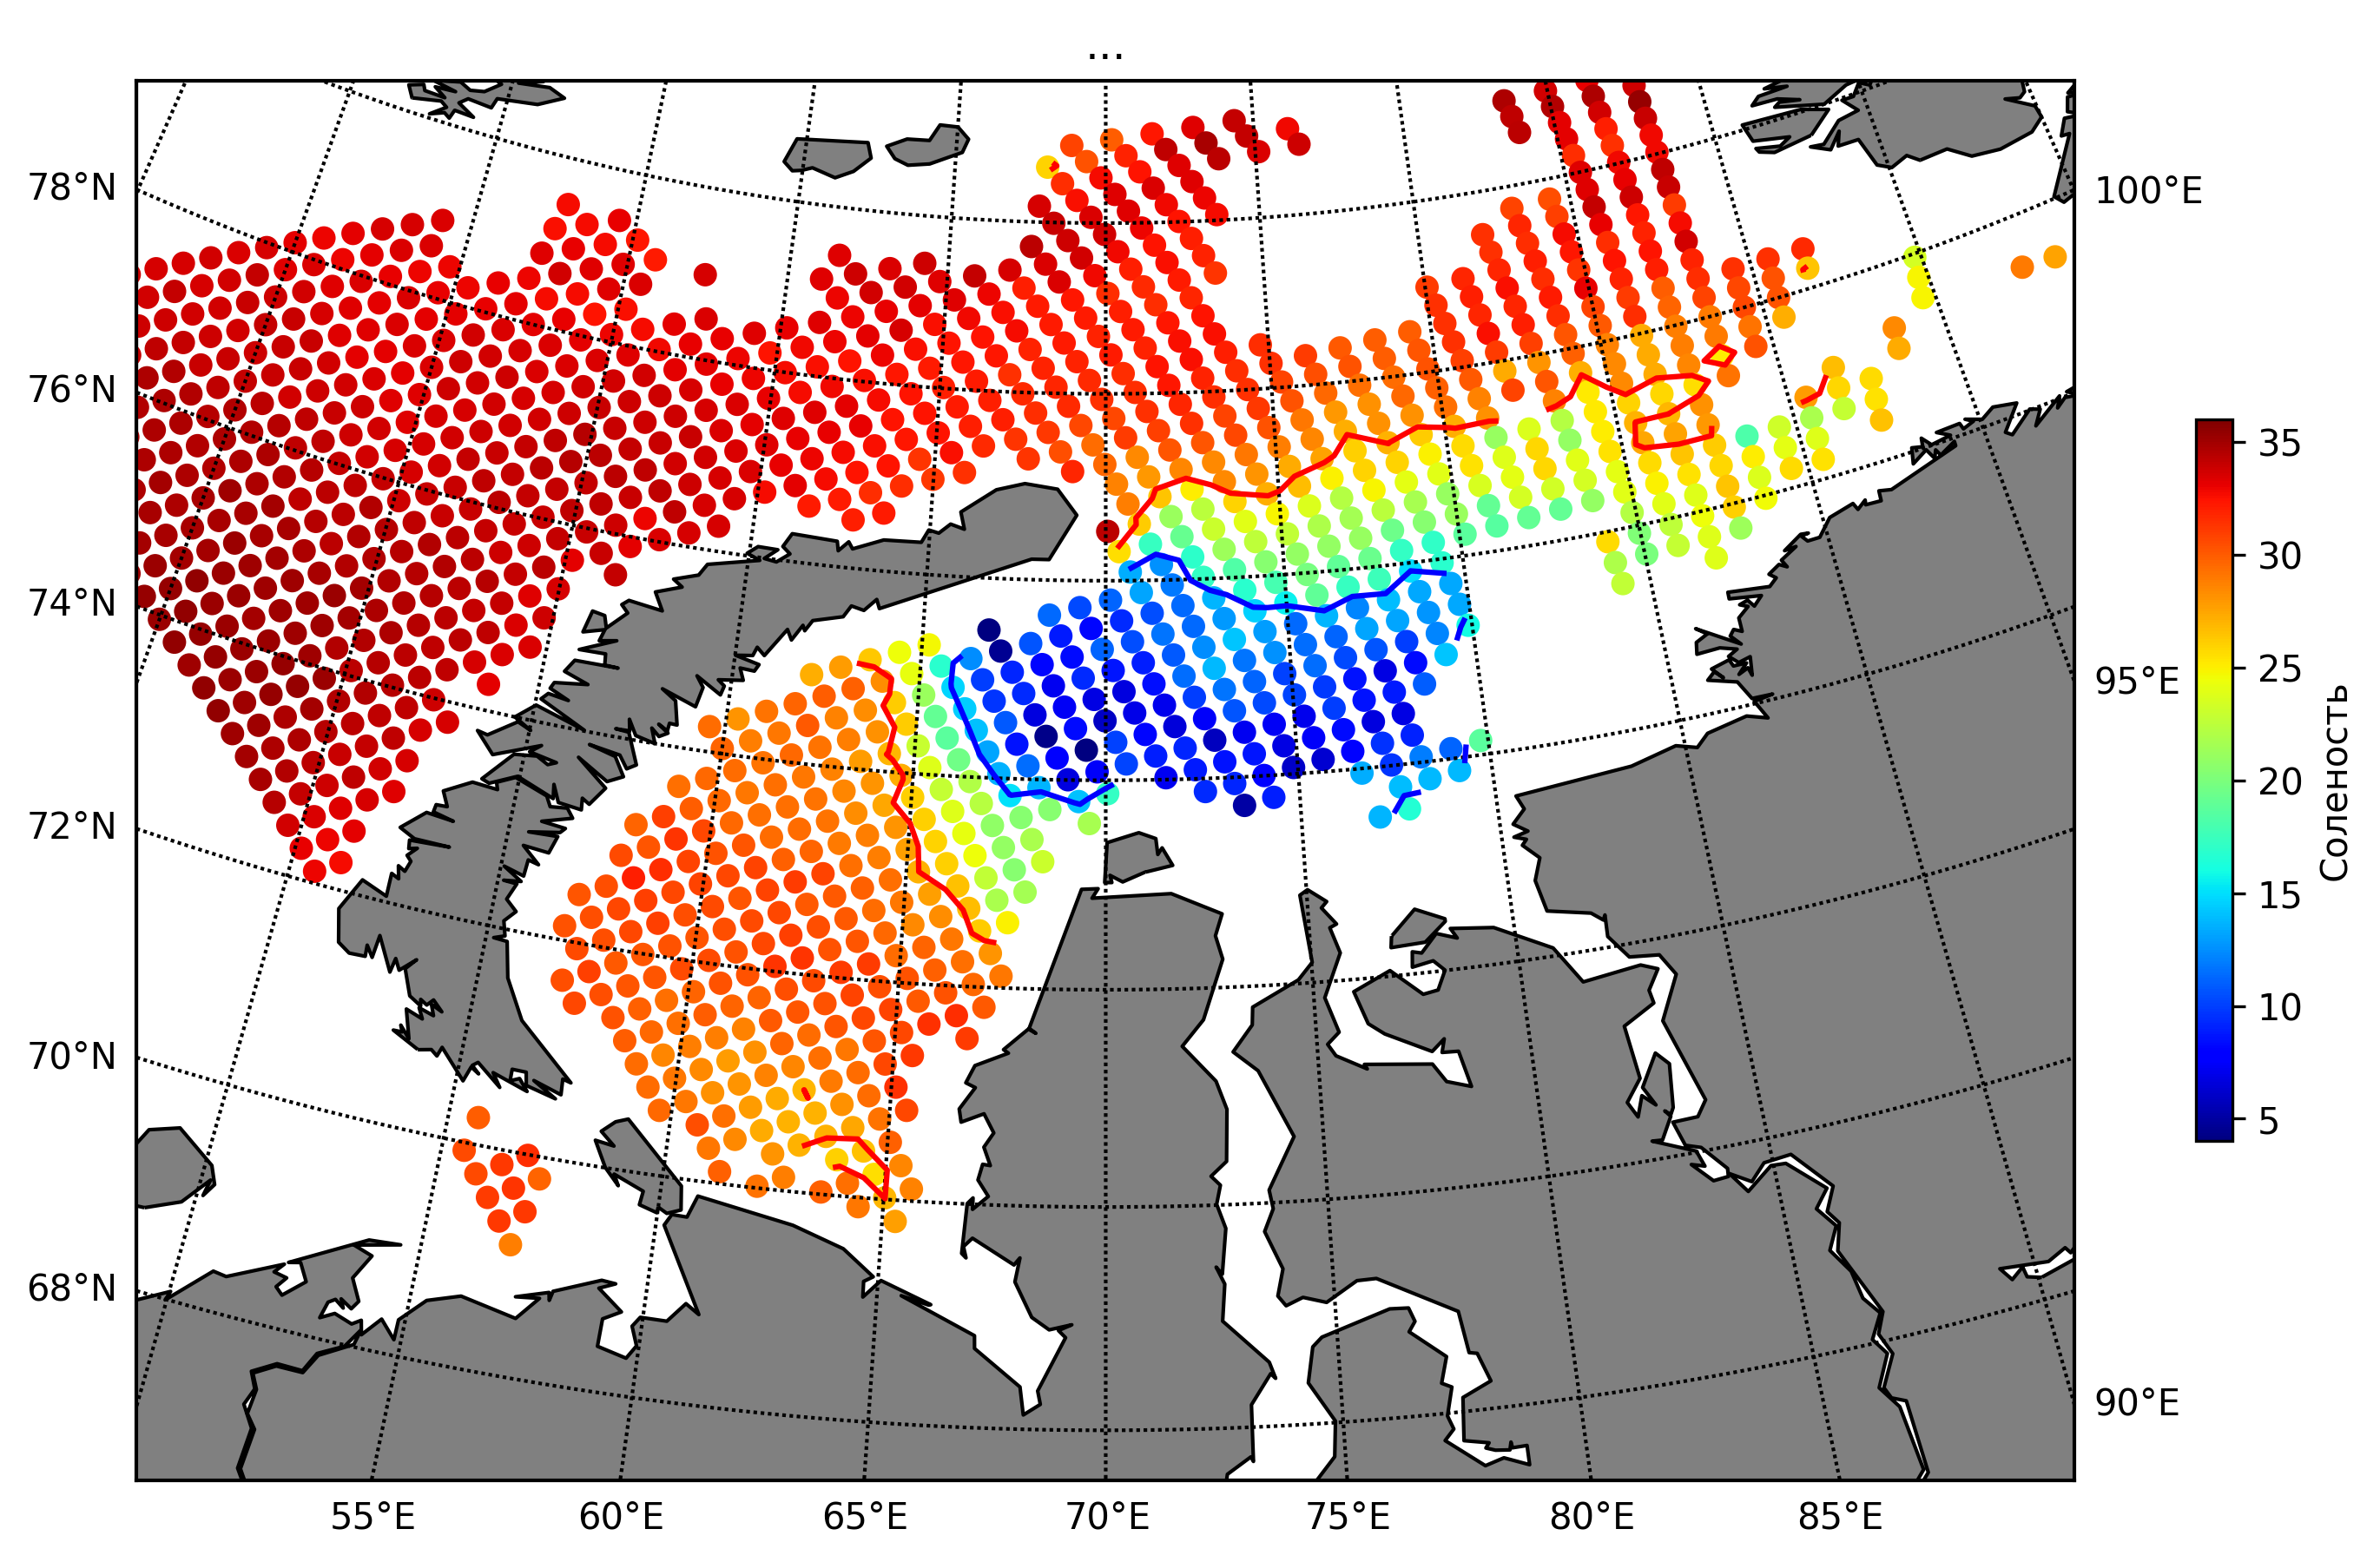

In [20]:
drawing(lon=lon, lat=lat, data=sss_, region='Kara', data_type='sss', day='...')

In [ ]:
drawing(lon=lon, lat=lat, data=sss_, region='EastSib', data_type='sss', day='...')

In [ ]:
sss_upd = np.where((lon < 55) | (lon > 105), np.nan, sss_)
sss_upd.shape

In [ ]:
drawing(lon=lon, lat=lat, data=sss_upd, region='Kara', data_type='sss', day='...')

In [ ]:
lon_flat = lon.ravel()
lat_flat = lat.ravel()
data_flat = sss_.ravel()

points = np.column_stack((lon_flat, lat_flat))  # (N, 2)

dlat = 0.125
dlon = 0.5

lat_new = np.arange(70, 80 + dlat, dlat)
lon_new = np.arange(55, 105 + dlon, dlon)

lon_small2d, lat_small2d = np.meshgrid(lon_new, lat_new)

# Линейная интерполяция (по сути билинейная в треугольниках триангуляции)
data_small2d = griddata(
    points,
    data_flat,
    (lon_small2d, lat_small2d),
    method='linear'
)

In [ ]:
lon_small2d.shape, lat_small2d.shape, data_small2d.shape

In [ ]:
drawing(lon=lon_small2d, lat=lat_small2d, data=data_small2d, region='Kara', data_type='sss', day='...')